In [2]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import matplotlib.pyplot as plt
import time

# --- HYPERPARAMETERS ---
batch_size = 32
block_size = 64
max_iters = 3000 # Increase to 10k for deep "overshooting"
eval_interval = 100
device = 'mps' if torch.backends.mps.is_available() else 'cpu'
n_embd = 128
n_head = 4
n_layer = 4
dropout = 0.1
eta = 1e-3  # Sensitivity tolerance from paper

# --- DATA PREP (Minimal Shakespeare) ---
#!wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

chars = sorted(list(set(text)))
vocab_size = len(chars)
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s]
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9*len(data))
train_data, val_data = data[:n], data[n:]

def get_batch(split):
    data_ptr = train_data if split == 'train' else val_data
    ix = torch.randint(len(data_ptr) - block_size, (batch_size,))
    x = torch.stack([data_ptr[i:i+block_size] for i in ix])
    y = torch.stack([data_ptr[i+1:i+block_size+1] for i in ix])
    return x.to(device), y.to(device)

# --- THE RESEARCH SURROGATE ---
def get_sensitivity(model, x):
    model.eval()
    # Embed tokens to get a continuous input for the Jacobian
    with torch.no_grad():
        # We perturb the embeddings (continuous) rather than discrete tokens
        emb = model.transformer.wte(x) + model.transformer.wpe(torch.arange(block_size, device=device))
        
        v = torch.randn_like(emb)
        v = v / torch.norm(v, p=2) # Unit vector
        
        # Original Forward pass (starting from embeddings)
        logits_orig = model.forward_from_embeddings(emb)
        # Perturbed Forward pass
        logits_pert = model.forward_from_embeddings(emb + eta * v)
        
        # S = ||f(x + n*v) - f(x)|| / n
        sensitivity = torch.norm(logits_pert - logits_orig, p='fro') / eta
    model.train()
    return sensitivity.item()

# The Transformer Architecture

In [5]:
class Head(nn.Module):
    """ One head of self-attention """
    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)   # (B, T, head_size)
        q = self.query(x) # (B, T, head_size)
        # Compute attention scores ("affinities")
        wei = q @ k.transpose(-2, -1) * k.shape[-1]**-0.5
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)
        # Perform the weighted aggregation of the values
        v = self.value(x)
        out = wei @ v
        return out

class MultiHeadAttention(nn.Module):
    """ Multiple heads of self-attention in parallel """
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(head_size * num_heads, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

class FeedForward(nn.Module):
    """ A simple linear layer followed by a non-linearity """
    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    """ Transformer block: communication followed by computation """
    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedForward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

In [3]:
class GPT(nn.Module):
    def __init__(self):
        super().__init__()
        self.transformer = nn.ModuleDict(dict(
            wte = nn.Embedding(vocab_size, n_embd),
            wpe = nn.Embedding(block_size, n_embd),
            drop = nn.Dropout(dropout),
            h = nn.ModuleList([Block(n_embd, n_head) for _ in range(n_layer)]),
            ln_f = nn.LayerNorm(n_embd),
        ))
        self.lm_head = nn.Linear(n_embd, vocab_size, bias=False)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        pos = torch.arange(0, T, dtype=torch.long, device=device)
        x = self.transformer.wte(idx) + self.transformer.wpe(pos)
        x = self.transformer.drop(x)
        for block in self.transformer.h: x = block(x)
        x = self.transformer.ln_f(x)
        logits = self.lm_head(x)
        loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1)) if targets is not None else None
        return logits, loss

    def forward_from_embeddings(self, x):
        # Used for sensitivity calculation
        for block in self.transformer.h: x = block(x)
        x = self.transformer.ln_f(x)
        return self.lm_head(x)

# [Generic Transformer Block/Attention code would go here—use standard GPT-2 block]

# The Training & Plotting Loop

Starting Stable Run...
Iter 0: Loss 4.3899, Sensitivity 0.2994
Iter 100: Loss 2.7259, Sensitivity 0.2838
Iter 200: Loss 2.5693, Sensitivity 0.3038
Iter 300: Loss 2.5165, Sensitivity 0.3326
Iter 400: Loss 2.4191, Sensitivity 0.3601
Iter 500: Loss 2.4059, Sensitivity 0.3883
Iter 600: Loss 2.3159, Sensitivity 0.4055
Iter 700: Loss 2.2660, Sensitivity 0.4294
Iter 800: Loss 2.2673, Sensitivity 0.4509
Iter 900: Loss 2.1800, Sensitivity 0.4688
Iter 1000: Loss 2.2228, Sensitivity 0.4943
Iter 1100: Loss 2.1072, Sensitivity 0.4981
Iter 1200: Loss 2.0788, Sensitivity 0.5065
Iter 1300: Loss 2.0914, Sensitivity 0.5200
Iter 1400: Loss 2.0218, Sensitivity 0.5287
Iter 1500: Loss 2.0909, Sensitivity 0.5269
Iter 1600: Loss 2.0082, Sensitivity 0.5378
Iter 1700: Loss 1.9343, Sensitivity 0.5388
Iter 1800: Loss 2.0091, Sensitivity 0.5588
Iter 1900: Loss 2.0361, Sensitivity 0.5632
Iter 2000: Loss 2.0246, Sensitivity 0.5687
Iter 2100: Loss 1.9343, Sensitivity 0.5877
Iter 2200: Loss 1.8988, Sensitivity 0.6050


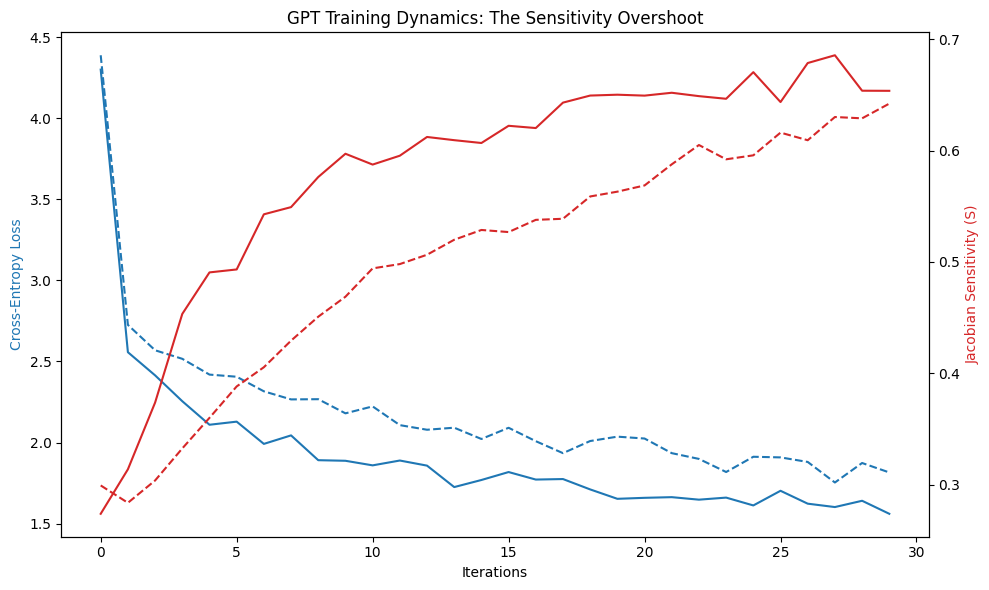

In [6]:
def train_research_mission(mode='stable'):
    model = GPT().to(device)
    lr = 3e-4 if mode == 'stable' else 1e-3
    wd = 0.1 if mode == 'stable' else 0.0
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    
    history = {'loss': [], 'sensitivity': []}
    
    for i in range(max_iters):
        xb, yb = get_batch('train')
        logits, loss = model(xb, yb)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        
        if i % eval_interval == 0:
            s = get_sensitivity(model, xb)
            history['loss'].append(loss.item())
            history['sensitivity'].append(s)
            print(f"Iter {i}: Loss {loss.item():.4f}, Sensitivity {s:.4f}")
            
    return history

# Run both experiments
print("Starting Stable Run...")
stable_data = train_research_mission('stable')
print("Starting Unstable (Overshoot) Run...")
unstable_data = train_research_mission('unstable')

# --- PLOT THE RESULTS ---
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel('Iterations')
ax1.set_ylabel('Cross-Entropy Loss', color='tab:blue')
ax1.plot(stable_data['loss'], color='tab:blue', linestyle='--', label='Stable Loss')
ax1.plot(unstable_data['loss'], color='tab:blue', label='Unstable Loss')

ax2 = ax1.twinx()
ax2.set_ylabel('Jacobian Sensitivity (S)', color='tab:red')
ax2.plot(stable_data['sensitivity'], color='tab:red', linestyle='--', label='Stable Sensitivity')
ax2.plot(unstable_data['sensitivity'], color='tab:red', label='Overshooting Sensitivity')

plt.title('GPT Training Dynamics: The Sensitivity Overshoot')
fig.tight_layout()
plt.show()

In [7]:
def count_parameters(model):
    # Total parameters (including those that don't require gradients)
    total_params = sum(p.numel() for p in model.parameters())
    # Trainable parameters (usually what people report)
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print(f"Total Parameters: {total_params:,}")
    print(f"Trainable Parameters: {trainable_params:,}")

# Usage:
model = GPT().to(device)
count_parameters(model)

Total Parameters: 816,640
Trainable Parameters: 816,640


In [12]:
def train_research_mission(mode='stable'):
    model = GPT().to(device)
    lr = 3e-4 if mode == 'stable' else 1e-3
    wd = 0.1 if mode == 'stable' else 0.0
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    
    # --- CRITICAL: Initialize history before the loop ---
    history = {
        'loss': [], 
        'sensitivity': [], 
        'val_robustness': [] # Added to track the Y-axis for your quadratic fit
    }
    
    for i in range(max_iters):
        xb, yb = get_batch('train')
        logits, loss = model(xb, yb)
        
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        
        # Track metrics periodically
        if i % eval_interval == 0:
            s = get_sensitivity(model, xb)
            
            # Record data into history
            history['loss'].append(loss.item())
            history['sensitivity'].append(s)
            
            # To plot the Quadratic Fit, you also need robustness (OOD accuracy)
            # You can use a simple character-swap on the validation batch here
            robustness = get_val_robustness(model) 
            history['val_robustness'].append(robustness)
            
            print(f"Iter {i}: Loss {loss.item():.4f}, Sensitivity {s:.4f}")
            
    return history

In [13]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

def plot_quadratic_fit(sensitivity_data, robustness_data):
    """
    Fits a 2nd-degree polynomial to prove the 'Optimal Band' theory.
    """
    # Convert lists to numpy arrays and reshape for sklearn
    S = np.array(sensitivity_data).reshape(-1, 1)
    R = np.array(robustness_data).reshape(-1, 1)
    
    # 1. Create quadratic features: [1, S, S^2]
    poly = PolynomialFeatures(degree=2)
    S_poly = poly.fit_transform(S)
    
    # 2. Fit the linear regression
    model = LinearRegression()
    model.fit(S_poly, R)
    
    # 3. Generate points for the smooth curve plot
    S_range = np.linspace(S.min(), S.max(), 100).reshape(-1, 1)
    S_range_poly = poly.transform(S_range)
    R_pred = model.predict(S_range_poly)
    
    # 4. Calculate the Peak (Optimal Sensitivity S*)
    # For y = ax^2 + bx + c, the peak is at x = -b / 2a
    coef = model.coef_.flatten() # [intercept, b, a]
    b = coef[1]
    a = coef[2]
    s_star = -b / (2 * a)
    
    # --- Plotting ---
    plt.figure(figsize=(8, 5))
    plt.scatter(S, R, color='black', alpha=0.5, label='Actual Checkpoints')
    plt.plot(S_range, R_pred, color='red', linewidth=2, label=f'Quadratic Fit (Peak S* ≈ {s_star:.3f})')
    
    plt.axvline(x=s_star, color='gray', linestyle='--', label='Optimal Sensitivity')
    plt.xlabel('Jacobian Sensitivity (S)')
    plt.ylabel('Robustness (OOD Accuracy)')
    plt.title('Validation of the Optimal Sensitivity Band')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return s_star


In [14]:
# Usage after training:
s_star = plot_quadratic_fit(history['sensitivity'], history['val_robustness'])

NameError: name 'history' is not defined